<a href="https://colab.research.google.com/github/Subham-Singh-369/OIBSIP/blob/main/DataScience-Task2-UnemploymentAnalysis/Unemployment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India.csv


In [2]:
import pandas as pd
df = pd.read_csv('Unemployment in India.csv')  # match the exact filename you uploaded
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [4]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nUnique regions:", df['Region'].nunique())
print("\nUnique Area values:", df['Area'].unique())

Shape: (768, 7)

Data types:
 Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

Missing values:
 Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

Unique regions: 28

Unique Area values: ['Rural' nan 'Urban']


In [11]:
df.columns = df.columns.str.strip()

# Check if 'Date' column is not already datetime type before processing
if not pd.api.types.is_datetime64_any_dtype(df['Date']):
    # Only strip if it's currently an object/string type
    if pd.api.types.is_object_dtype(df['Date']):
        df['Date'] = df['Date'].str.strip()
    # Convert to datetime
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Strip whitespace from Region/Area just in case, only if they are object types
if pd.api.types.is_object_dtype(df['Region']):
    df['Region'] = df['Region'].str.strip()
if pd.api.types.is_object_dtype(df['Area']):
    df['Area'] = df['Area'].str.strip()

df.dtypes

,0
Region,object
Date,datetime64[ns]
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


In [12]:
print("Current shape:", df.shape)
print("\nMissing values now:\n", df.isnull().sum())

Current shape: (740, 7)

Missing values now:
 Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [13]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Month_Year'] = df['Date'].dt.to_period('M')

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Month,Year,Month_Year
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,5,2019,2019-05
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,6,2019,2019-06
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,7,2019,2019-07
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,8,2019,2019-08
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,9,2019,2019-09


In [14]:
df.describe()


,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Month,Year
count,740,740.000000,7.400000e+02,740.000000,740.000000,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122,6.390541,2019.418919
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000,1.000000,2019.000000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500,4.000000,2019.000000
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000,6.000000,2019.000000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000,9.000000,2020.000000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000,12.000000,2020.000000
std,NaN,10.721298,8.087988e+06,8.111094,3.235070,0.493716


In [17]:
print(sorted(df['Region'].unique()))

['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


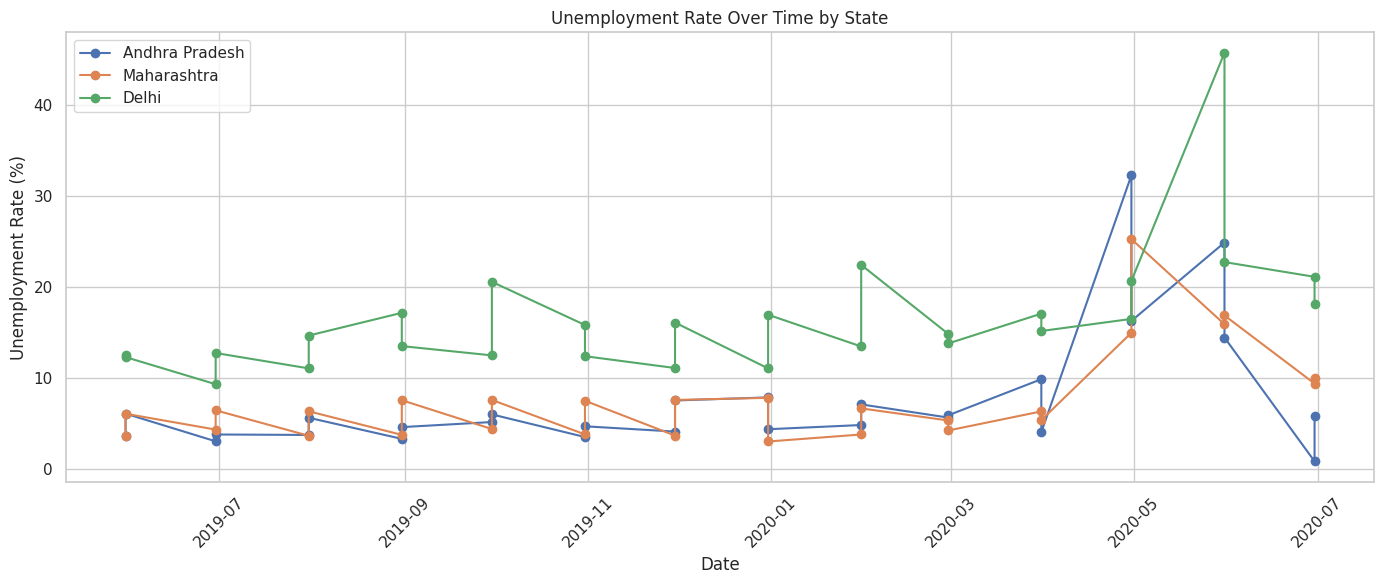

In [15]:
states_to_plot = ['Andhra Pradesh', 'Maharashtra', 'Delhi']

plt.figure(figsize=(14, 6))
for state in states_to_plot:
    state_data = df[df['Region'] == state].sort_values('Date')
    plt.plot(state_data['Date'], state_data['Estimated Unemployment Rate (%)'], marker='o', label=state)

plt.title('Unemployment Rate Over Time by State')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_693/1342505617.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')


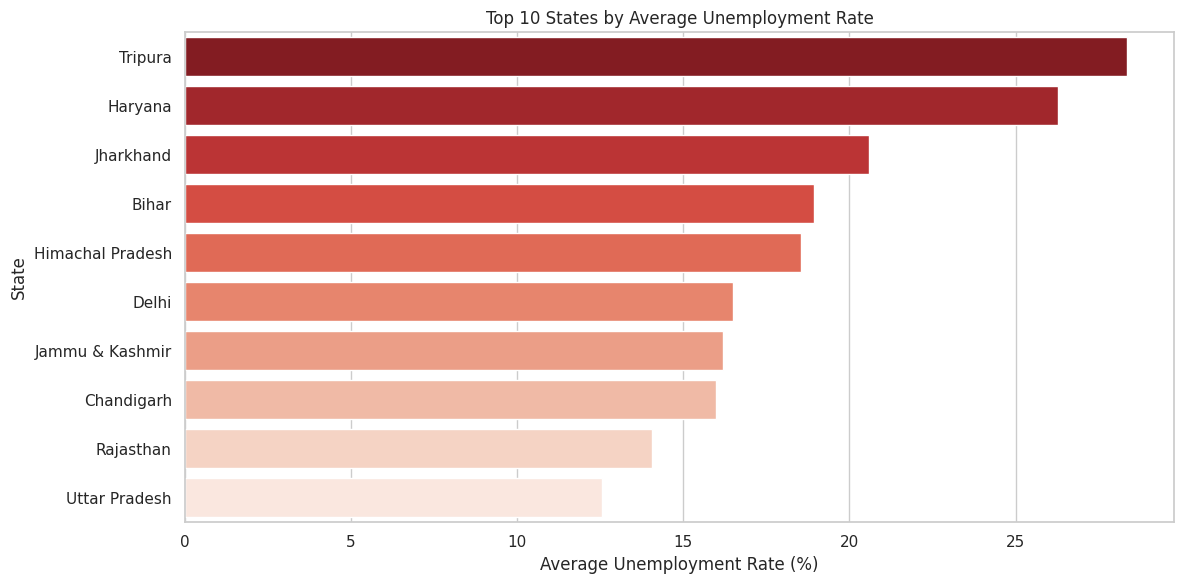

In [16]:
top10 = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')
plt.title('Top 10 States by Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Observations — Time-Series & Top States

The time-series chart shows unemployment rates for Andhra Pradesh,
Maharashtra, and Delhi holding relatively stable (roughly 3-8%) through
late 2019 and early 2020. Delhi consistently ran higher than the other
two states even before COVID-19.

Starting around April 2020, all three states show a sharp, simultaneous
spike — Delhi peaks near 46%, Andhra Pradesh near 32% — coinciding
exactly with India's nationwide COVID-19 lockdown (announced March 2020).
This is the clearest signal in the dataset.

The top-10 bar chart (Tripura ~28%, Haryana ~26%, Jharkhand ~20%, followed
by Bihar, Himachal Pradesh, and Delhi) reflects average unemployment across
the *entire* dataset period, so these high averages are heavily influenced
by the COVID-19 spike months rather than representing typical pre-pandemic
conditions in these states.

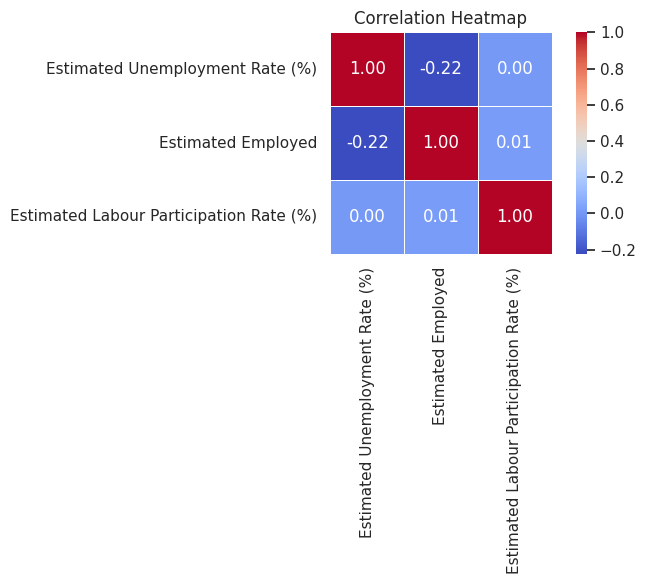

In [18]:
numeric_cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [19]:
# Define COVID cutoff — India's lockdown began late March 2020
pre_covid = df[df['Date'] < '2020-03-01']
post_covid = df[df['Date'] >= '2020-03-01']

comparison = pd.DataFrame({
    'Pre-COVID (avg)': [
        pre_covid['Estimated Unemployment Rate (%)'].mean(),
        pre_covid['Estimated Employed'].mean(),
        pre_covid['Estimated Labour Participation Rate (%)'].mean()
    ],
    'Post-COVID (avg)': [
        post_covid['Estimated Unemployment Rate (%)'].mean(),
        post_covid['Estimated Employed'].mean(),
        post_covid['Estimated Labour Participation Rate (%)'].mean()
    ]
}, index=['Unemployment Rate (%)', 'Employed', 'Labour Participation Rate (%)'])

comparison

,Pre-COVID (avg),Post-COVID (avg)
Unemployment Rate (%),9.509534e+00,1.777436e+01
Employed,7.466028e+06,6.517203e+06
Labour Participation Rate (%),4.388612e+01,3.933005e+01


## Observations — Correlation & Pre/Post-COVID Impact

The correlation heatmap shows a weak negative relationship between
Unemployment Rate and Estimated Employed (-0.22), which is intuitive but
weaker than expected — likely because employment counts are heavily
influenced by each state's population size, not just its unemployment
rate. Labour Participation Rate shows almost no linear correlation with
either variable (~0.00–0.01), suggesting participation dynamics during
this period were driven more by external shocks (like lockdowns) than by
a steady relationship with unemployment or employment levels.

The pre/post-COVID comparison reveals a stark shift:
- **Unemployment rate nearly doubled**, from 9.51% pre-COVID to 17.77% post-COVID.
- **Estimated employment dropped** by ~950,000 on average.
- **Labour participation rate fell** from 43.9% to 39.3%, indicating that a
  meaningful share of the workforce exited the labour market entirely
  during the pandemic rather than simply becoming unemployed while still
  seeking work (a "discouraged worker" effect).

This aligns with well-documented real-world impacts of India's March 2020
COVID-19 lockdown on the labour market.

## Conclusion & Recommendations

1. **Targeted state-level support:** States like Tripura, Haryana, and
   Jharkhand showed the highest average unemployment rates over this
   period and should be prioritized for employment recovery programs.

2. **Monitor labour force exits, not just unemployment:** The drop in
   labour participation rate suggests standard unemployment figures may
   understate the true impact of economic shocks — policies should track
   participation rate alongside unemployment rate.

3. **Prepare for shock-driven spikes:** The sharp April-June 2020 spike
   shows unemployment can shift dramatically within a single quarter
   during external shocks, reinforcing the need for rapid-response
   safety-net programs (unemployment benefits, emergency employment
   schemes) that can scale quickly.